# Some semi-analiytical considerations for momentum-driven slow extraction

In [ ]:
import sys
from pathlib import Path

# Add repo root to sys.path so 'crystal_extraction' is importable
# regardless of where Jupyter's working directory is
_repo_root = Path().resolve()
if _repo_root.name == "Notebooks":
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2
%matplotlib widget


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xtrack as xt
#import xplt

import crystal_extraction.plotters as plotters
import crystal_extraction.steinbach as st

plotters.my_mpl_style()

ModuleNotFoundError: No module named 'crystal_extraction'

## Load optics

In [ ]:
line = xt.Line.from_json('database/lhc_q20.json')

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

KeyError: 'RBend'

In [ ]:
teca_marker = xt.Marker()
line.insert('teca.41777', teca_marker, at=-7.2, from_='tpsc4.41797')

Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

In [ ]:
teca = st.sps_crystal.copy()
beam_args = st.BeamArgs()
stein_args = st.SteinArgs()

In [ ]:
stein = st.Steinbach(line, teca, beam_args, stein_args)
stein.line.particle_ref = xt.Particles(mass0=beam_args.mass0,
                                    p0c=beam_args.p0c)

In [ ]:
tw = stein.line.twiss(method="4d")

In [ ]:
#xplt.TwissPlot(tw, kind="bet, dx")

In [ ]:
# crystal locations

df = stein.parse_xsuite_twiss(tw)

Text(0.5, 0, 's [m]')

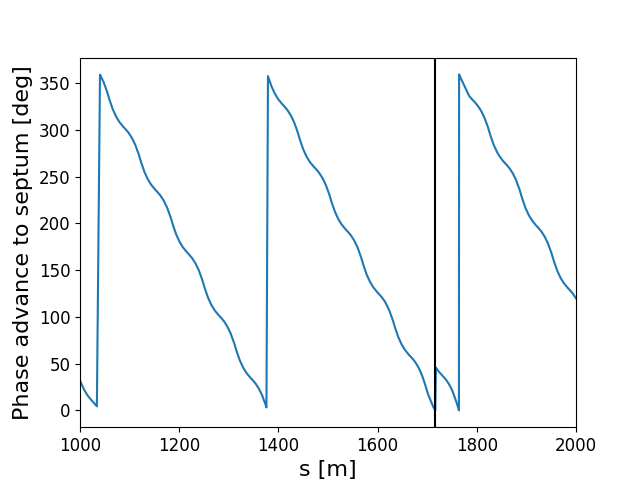

In [ ]:
plt.plot(df.s, df.mux_to_sep_deg)
plt.axvline(df.loc[stein.stein_args.septum_loc].s, color='k')
plt.xlim(1000, 2000)
plt.ylabel('Phase advance to septum [deg]')
plt.xlabel('s [m]')

# Look for interesting locations

In [ ]:
only_drift = df.index.str.startswith('drift')
only_long = True #df_s.l > 0.5
only_good_phase = (np.abs(df.mux_to_sep_deg-90)<10) | (np.abs(df.mux_to_sep_deg-270)<10)
only_good_dpp = df.dpp_stopband_rms_rel < 0.2
df_plot = df[only_drift&only_long&only_good_phase&only_good_dpp].sort_values('s')
df_plot[['dpp_stopband_rms_rel',
        'dxp_stopband_rel',
        'gap_to_sep_mm',
        'gap_to_sep_in_sigma',
        'mux_to_sep_deg']].head(5)

,dpp_stopband_rms_rel,dxp_stopband_rel,gap_to_sep_mm,gap_to_sep_in_sigma,mux_to_sep_deg
name,,,,,
drift_20,-0.163301,1.956577,-9.668189,-9.193834,278.472439
drift_21,-0.181170,2.671779,-8.488745,-9.294211,269.132978
drift_22,-0.184829,2.891506,-8.315469,-9.286629,267.528502
drift_23,-0.187223,3.031879,-8.212409,-9.278369,266.543846
drift_mdv.10307..1,-0.187879,3.069925,-8.185409,-9.275712,266.282108


Text(0, 0.5, 'betx (m)')

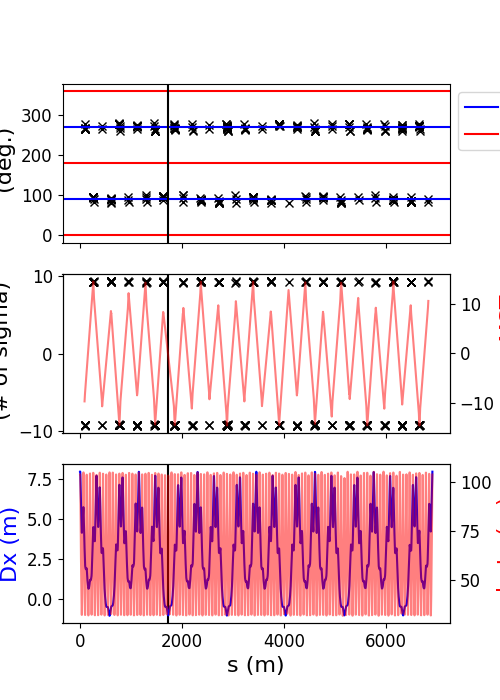

In [ ]:
f, ax = plt.subplots(3, 1, sharex=True, figsize=(5, 7))
ax[0].plot(df_plot.s, df_plot.mux_to_sep_deg, marker='x', linestyle='none', color='black')
ax[0].axhline(90, color='blue')
ax[0].axhline(270, color='blue', label='Optimal mux')
ax[0].axhline(180, color='red', label='Anti-Optimal mux')
ax[0].axhline(360, color='red')
ax[0].axhline(0, color='red')
ax[0].axvline(df.loc[stein.stein_args.septum_loc].s, color='black')
ax[0].set_ylabel('mux to mst \n (deg.)')
ax[0].legend(bbox_to_anchor=(1, 1))

ax[1].plot(df_plot.s, df_plot.gap_to_sep_in_sigma, marker='x',
            linestyle='none', color='black')
ax_mst_mm = ax[1].twinx()
ax_mst_mm.plot(df_plot.s, df_plot.gap_to_sep_mm, color='red', alpha=0.5)
ax_mst_mm.set_ylabel('gap at MST \n (mm)', color='red')
ax[1].axvline(df.loc[stein.stein_args.septum_loc].s, color='black')
ax[1].set_ylabel('gap at MST \n (# of sigma)')

ax[2].axvline(df.loc[stein.stein_args.septum_loc].s, color='black')
ax_beta = ax[2].twinx()
ax[2].plot(df.s, df.dx, color='blue', alpha=1)
ax_beta.plot(df.s, df.betx, color='red', alpha=0.5)
ax[2].set_xlabel('s (m)')
ax[2].set_ylabel('Dx (m)', color='blue')
ax_beta.set_ylabel('betx (m)', color='red')



Twiss not provided, computing from line...


-0.0007384755492931384


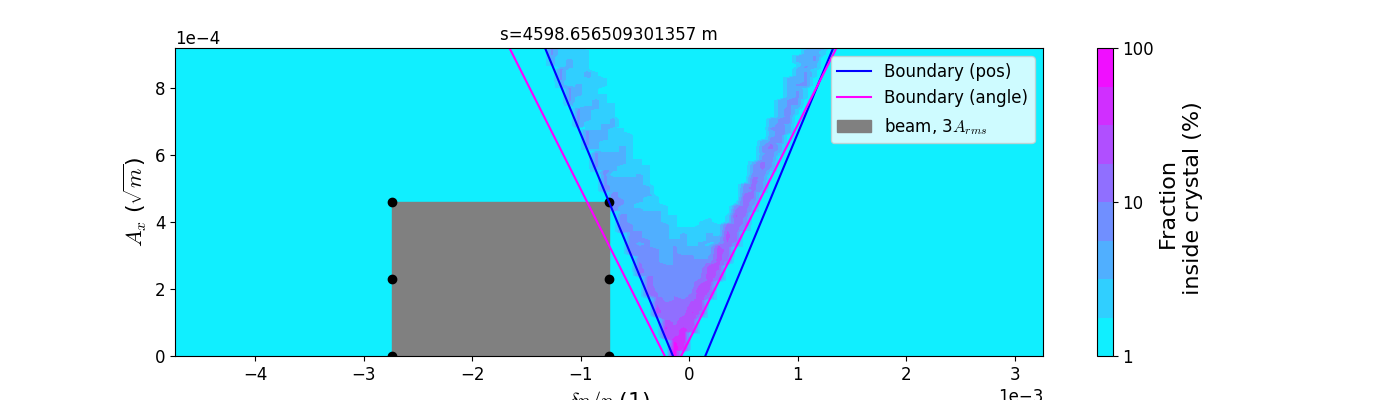

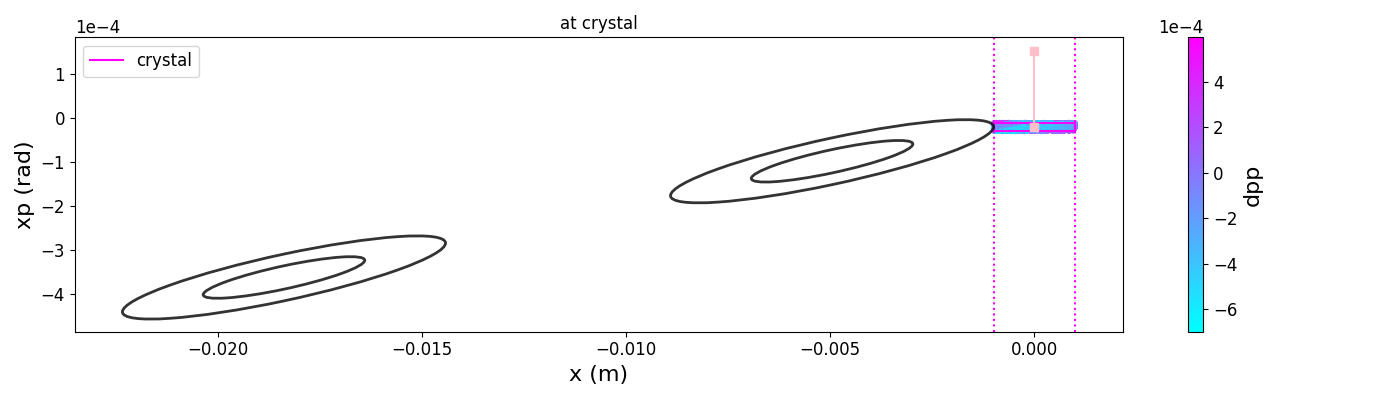

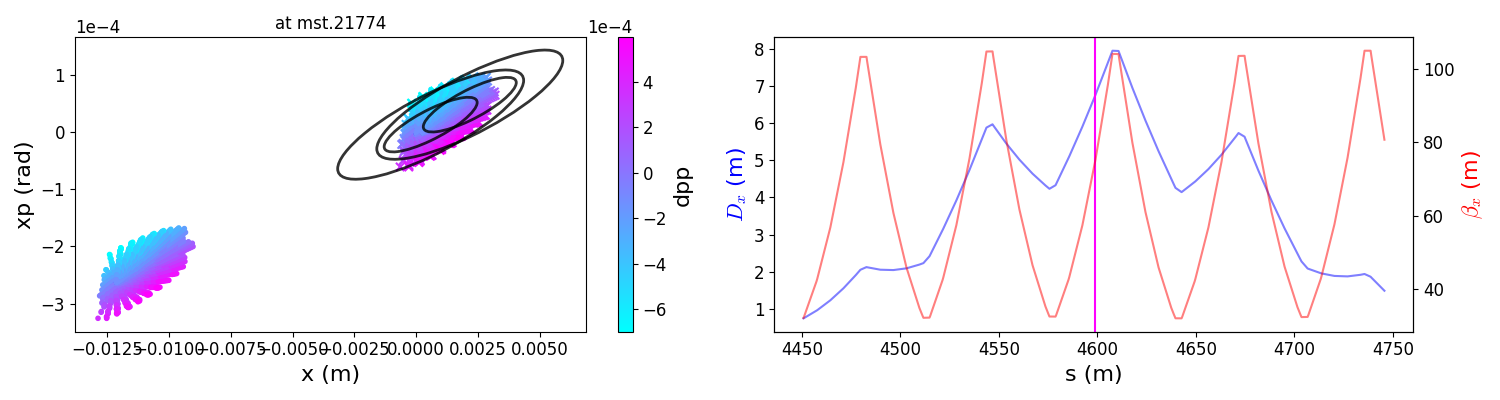

In [ ]:
# Example of steinbach plot @ good location 

stein.stein_args.crystal_loc = "drift_1239"
stein.plot();

Twiss not provided, computing from line...


-0.005939121266232721


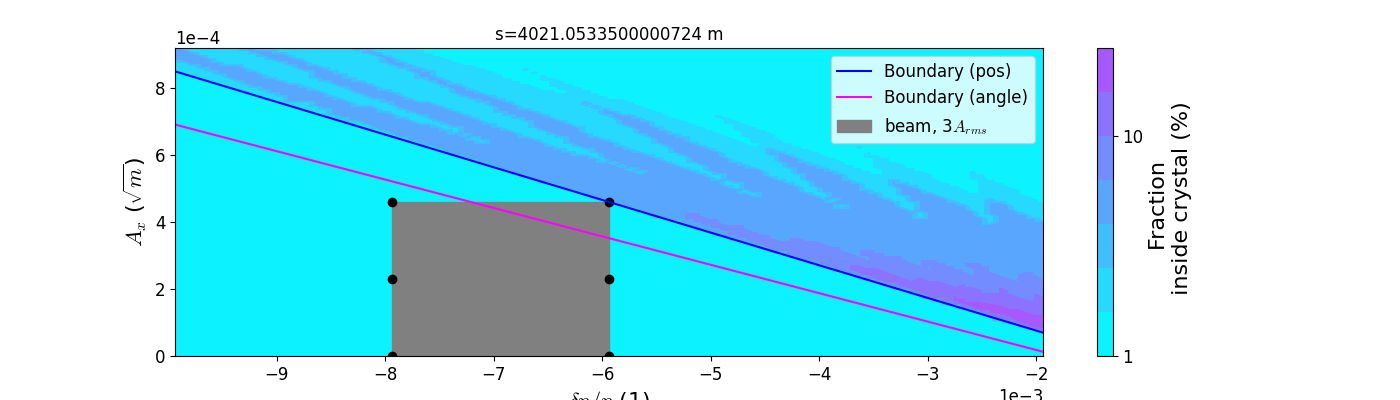

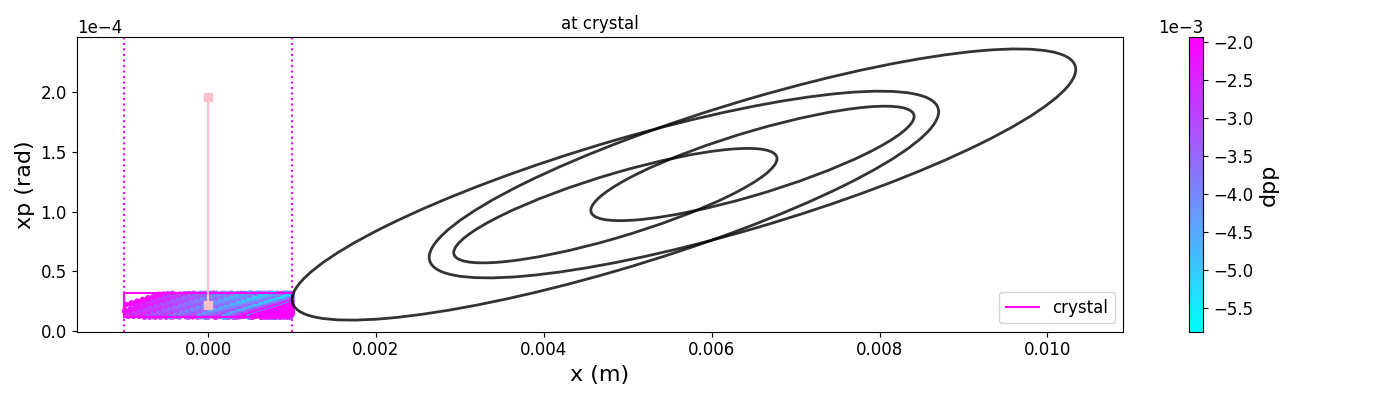

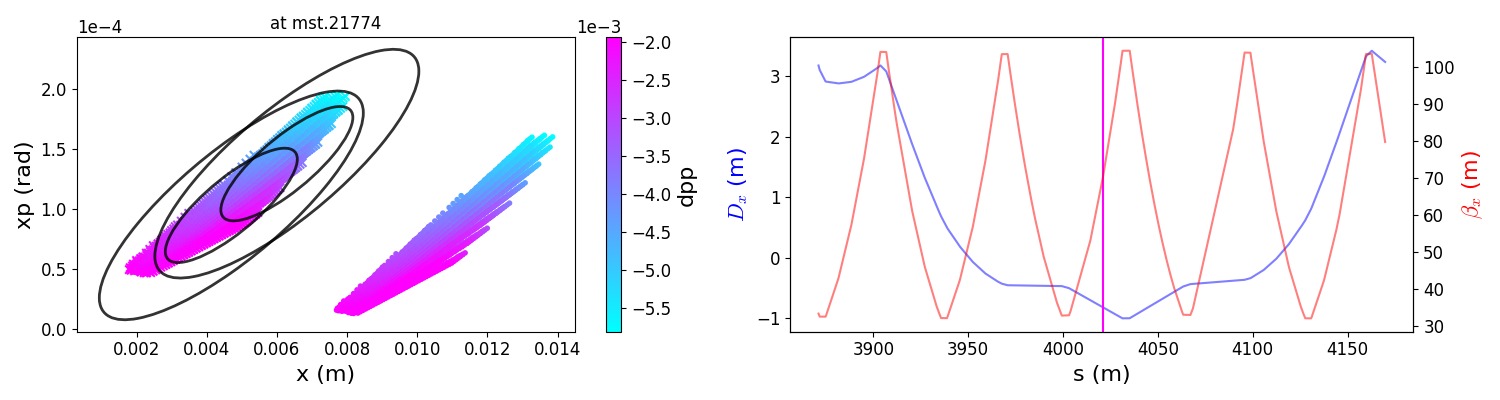

In [ ]:
# example of steinbach plot @ teca location

stein.stein_args.crystal_loc = "teca.41777"
stein.plot();